[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/snow0369/qiskit_handson_260827/blob/main/grovers_algorithm_tutorial.ipynb)

# Grover's Algorithm: A Hands-On Introduction

**Author:** Gwonhak Lee, PhD, IBM Quantum, Quantum Algorithm Engineer


Welcome! This notebook is for people who just learned the basics of Qiskit (you know what a qubit, a gate, and a circuit are) and want to understand and build their **first real quantum algorithm**.

### What you'll learn

1. The classical search problem, and why Grover's algorithm beats it.
2. The two building blocks of Grover's algorithm: the **oracle** and the **diffuser**.
3. How to build each of these in Qiskit, from simple examples to a general-purpose version.
4. How to run the full algorithm, measure results, and interpret them.
5. Why the number of iterations matters, and what happens if you get it wrong.

## 0. A bit of theory: why does this work at all?

"Quantum parallelism" sounds like it should give exponential speedup for free: put $n$ qubits into superposition, and you've evaluated $f$ on all $N = 2^n$ inputs "at once." **This is a myth.** You still only get to measure once, and a measurement just samples one basis state at random, with probability equal to its squared amplitude. If every amplitude starts equal, measuring right after superposition gives a uniformly random guess, no better than classical.

A common mental image of the myth: put a maze into superposition and it "magically" hands you back the shortest path. It doesn't: every path, dead ends included, is explored with equal amplitude, like buying every lottery ticket but still only drawing one at random. What actually finds the shortest path is **interference**, applied repeatedly, which cancels the false paths and amplifies the true one so it is what you actually measure:

![Left: myth -- the maze in superposition explores every path, dead ends and solution alike, with equal probability, like a lottery. Right: reality -- repeated quantum iterations cancel the dead-end paths and amplify the solution.](https://raw.githubusercontent.com/snow0369/qiskit_handson_260827/main/image/maze_myth.png)

**The real work is interference**: rearranging amplitudes so the right answer's probability becomes large *before* you measure.

### The myth, made concrete: superposition alone just picks one at random

Superposition means every outcome has *some* probability. But a measurement collapses the state to exactly one of them, chosen at random with that probability, and every other outcome vanishes:

![Before measurement: N waves, each with some probability. After measurement: one outcome survives with probability 1, the rest are 0.](https://raw.githubusercontent.com/snow0369/qiskit_handson_260827/main/image/state_collapse.png)

If every wave started at the same height (as it does right after $H^{\otimes n}|0\rangle$), that one surviving outcome is uniformly random. However, superposition by itself bought nothing. Interference is what makes the *right* outcome the likely survivor.

### Classical probability vs. quantum amplitude

Classical probabilities $p_i$ are non-negative and only ever add up. Quantum amplitudes $\alpha_i$ can be negative and **interfere**. The measurement gives outcome $i$ with probability $|\alpha_i|^2$, so $\sum_i |\alpha_i|^2 = 1$.

Each of the $N=2^4=16$ discrete outcomes of a 4-qubit state $|\psi\rangle = \sum_i \alpha_i|i\rangle$ drawn as its own wave, basis state below, probability above:

![N=2^4 discrete amplitude waves, basis state below and probability above each wave](https://raw.githubusercontent.com/snow0369/qiskit_handson_260827/main/image/classical_vs_quantum_prob.png)

This sign is exactly what makes the classic **double-slit experiment** so strange: fire particles through two slits, and a classical picture predicts two separate blobs on the screen (probabilities from each slit just add). Quantum mechanics instead produces a rippled **interference pattern**.

![Left: classical particles through two slits produce two separate blobs on the screen. Right: quantum amplitudes through two slits interfere, producing a fringed interference pattern.](https://raw.githubusercontent.com/snow0369/qiskit_handson_260827/main/image/double_slit.png)


### The wave picture: starting from equal footing

The starting state: uniform superposition $H^{\otimes n}|0\rangle = \frac{1}{\sqrt N}\sum_i |i\rangle$ ($N=2^4=16$) identical upright waves, each probability $1/N$:

![Initial uniform superposition as N equal waves](https://raw.githubusercontent.com/snow0369/qiskit_handson_260827/main/image/initial_superposition.png)

Nothing distinguishes the solution ($\bigstar$) yet. A measurement now returns a uniformly random outcome, exactly the "myth" from above.

### Phase flip, then inversion about the mean

1. **Oracle**: flips the solution's wave upside-down. Same height, same probability (a measurement right after still looks uniform).
2. **Diffuser (inversion about the mean)**: $\alpha_i \to 2\bar\alpha - \alpha_i$. The dotted line marks that mean $\bar\alpha$. Every wave is reflected about it. The solution was the only negative wave, so it lands far above the mean; everyone else, already close to it, barely moves.

![Oracle flips one wave, then inversion about the mean amplifies its probability, with a dotted line marking the mean amplitude](https://raw.githubusercontent.com/snow0369/qiskit_handson_260827/main/image/oracle_and_inversion.png)

This pair (**phase oracle + inversion about the mean**) is exactly the "oracle + diffuser" built explicitly in Sections 4–5 below; repeating it $r$ times concentrates probability onto the solution further, up to a point.

### Repeating the step: iteration builds up, then overshoots

Applying the pair again pushes the solution's probability up further, since the amplitudes are still not concentrated enough for a good measurement. But it doesn't help forever:

![Five small panels showing the amplitude distribution after r=0,1,2,3,4 Grover iterations for N=16 -- the solution's probability rises to 0.96 at the optimal r=3, then falls to 0.58 at r=4. A callout marks that r=2-3 iterations is far smaller than N=16 candidates.](https://raw.githubusercontent.com/snow0369/qiskit_handson_260827/main/image/iteration_progress.png)

For $N=16$ with a single solution, the optimal number of iterations is $r=\lfloor\frac{\pi}{4}\sqrt{N}\rfloor=3$, giving probability $0.96$. Push past that ($r=4$ above) and the solution's amplitude overshoots the peak and starts *shrinking*: more iterations is not always better, and Section 8 below revisits this "overshoot" behavior with real circuits.

Notice the scale: reaching $96\%$ success took just $r=3$ tries out of $N=16$ candidates, already better than random guessing by more than an order of magnitude for this tiny example, and the gap only widens as $N$ grows, since $r=O(\sqrt N)$ while classical search needs $O(N)$.

## 1. Setup

We need `qiskit` (the core library), `qiskit-aer` (a fast local simulator), and `qiskit-ibm-runtime` (for the real-hardware section later on). Run the cell below to install them; it's safe to run even if you already have them.

In [1]:
%pip install -q qiskit qiskit-aer qiskit-ibm-runtime matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import product

from qiskit import QuantumCircuit, transpile
from qiskit.circuit.library import MCMTGate, ZGate
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator
from qiskit_aer.primitives import SamplerV2 as Sampler

print("Setup complete.")

Setup complete.


## 2. The problem: searching an unsorted list

We have a function $f(x)$ over $N = 2^n$ possible inputs $x$ (encoded as $n$ bits):

$$
f(x) = \begin{cases} 1 & \text{if } x \text{ is the item we want (the "winner")} \\ 0 & \text{otherwise} \end{cases}
$$

We know nothing about $f$'s structure, we can only *evaluate* it. This is an **unstructured search problem**.

- **Classically**: $O(N)$ calls to $f$ in the worst case, $N/2$ on average. No way around it.
- **Grover's algorithm**: finds the winner using only $O(\sqrt{N})$ calls to a *quantum* version of $f$.

This quadratic speedup is provably optimal for fully unstructured search.

## 3. The core idea: amplitude amplification

Grover's algorithm doesn't check items one by one. It puts the computer into a **superposition of all $N$ possibilities**, then uses interference to boost the winner's probability while suppressing everything else.

Picture the quantum state as a vector in a 2D plane spanned by:

- $|w\rangle$: the winning state,
- $|s'\rangle$: the uniform superposition of all $N-1$ *other* states, $|s'\rangle = \frac{1}{\sqrt{N-1}}\sum_{x \neq w} |x\rangle$.

The starting state $|s\rangle = H^{\otimes n}|0\rangle^{\otimes n}$ is the uniform superposition over *all* $N$ states, so it decomposes exactly into these two orthogonal directions:

$$
|s\rangle = \sin\theta\,|w\rangle + \cos\theta\,|s'\rangle, \qquad \sin\theta = \frac{1}{\sqrt{N}}
$$

$|s\rangle$ sits at angle $\theta$ from $|s'\rangle$, close to $|s'\rangle$ with only a tiny sliver of $|w\rangle$, since $\theta \approx 1/\sqrt N$ is small for large $N$.

**One Grover iteration = two reflections:**

- **Oracle** ($U_f$): reflects across $|s'\rangle$ (flips the sign of $|w\rangle$ only). Applied to a general state $\sin\alpha\,|w\rangle+\cos\alpha\,|s'\rangle$, it sends $\alpha \to -\alpha$:

$$
U_f|s\rangle = -\sin\theta\,|w\rangle + \cos\theta\,|s'\rangle
$$

- **Diffuser** ($U_s = 2|s\rangle\langle s| - I$): reflects across $|s\rangle$ itself. Reflecting the angle $-\theta$ across $\theta$ lands at $2\theta-(-\theta) = 3\theta$:

$$
U_sU_f|s\rangle = \sin(3\theta)\,|w\rangle + \cos(3\theta)\,|s'\rangle
$$

Two reflections = a **rotation** by $2\theta$ toward $|w\rangle$: each full iteration advances the angle from $\theta$ to $3\theta$, i.e. $\theta \to \theta + 2\theta$. After $r$ iterations,

$$
\big(U_sU_f\big)^r|s\rangle = \sin\!\big((2r+1)\theta\big)\,|w\rangle + \cos\!\big((2r+1)\theta\big)\,|s'\rangle
$$

Repeat enough times and the state aligns with $|w\rangle$, measuring then gives the winner with high probability. Rotate *too many* times, though, and you overshoot past $|w\rangle$.

![Geometric picture of one Grover iteration: starting vector |s>, oracle reflects it across |s'> to U_f|s>, diffuser reflects that across |s> to U_sU_f|s>, a net rotation by 2*theta toward |w>.](https://raw.githubusercontent.com/snow0369/qiskit_handson_260827/main/image/one_iteration_rotation.png)

### Deriving the optimal iteration count

The probability of measuring the winner after $r$ iterations is $\sin^2\!\big((2r+1)\theta\big)$, which is maximized (equal to $1$) when $(2r+1)\theta = \pi/2$. Solving for $r$:

$$
r = \frac{\pi}{4\theta} - \frac{1}{2}
$$

Since $r$ must be a non-negative integer, we round to the nearest one, and for large $N$ (small $\theta \approx 1/\sqrt N$) the $-\tfrac12$ correction is negligible, giving the standard approximation:

$$
r \approx \left\lfloor \frac{\pi}{4\theta} \right\rfloor \approx \left\lfloor \frac{\pi}{4}\sqrt{N} \right\rfloor
$$

This $\sqrt{N}$ scaling, instead of the classical $O(N)$, is exactly where Grover's speedup comes from.

## 4. Building block 1: the Oracle

The oracle marks winning state(s) by flipping their phase, leaving everything else unchanged:

$$
U_f|x\rangle = \begin{cases} -|x\rangle & \text{if } x \text{ is a winner} \\ |x\rangle & \text{otherwise} \end{cases}
$$

Let's consider a boolean function $f(x)$, and we want to find bitstring $x$ that satisfies $f(x)=1$ (True).

### Warm-up: an oracle *is* a Boolean function

For example, take a two-bit function:
$$
f(x_1, x_2) = x_1 \land x_2\text{  (logical AND)}.
$$

Trivially, $f=1$ only when *both* bits are $1$, i.e. only on input $x_1x_2=11$.
A plain $CZ$ gate implements exactly this. This flips the phase iff both qubits are $|1\rangle$, and leaves every other state alone:

$$
U_f = CZ
$$

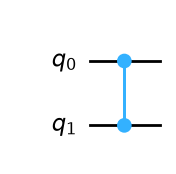

In [3]:
oracle_and = QuantumCircuit(2, name="Oracle(AND)")
oracle_and.cz(0, 1)
oracle_and.draw("mpl")

In [4]:
def oracle_check(oracle, n_qubits=2):
    """Print the phase factor oracle applies to every n_qubits basis state."""
    for bits in product(["0", "1"], repeat=n_qubits):
        label = "".join(bits)
        sv = Statevector.from_label(label)
        sv_after = sv.evolve(oracle)
        idx = np.argmax(np.abs(sv_after.data))
        amp = sv_after.data[idx]
        print(f"|{label}> -> phase factor {amp.real:+.0f}")


oracle_check(oracle_and)

|00> -> phase factor +1
|01> -> phase factor +1
|10> -> phase factor +1
|11> -> phase factor -1


### Exercise 1: What about logical OR?

Now try

$$
f(x_1, x_2) = x_1 \lor x_2 \text{  (logical OR)}
$$

A single $CZ$ can't do this alone (it only ever touches the all-ones case), so OR needs a different combination of gates.

**Hint: De Morgan's law**: $x_1 \lor x_2 = \lnot(\lnot x_1 \land \lnot x_2)$. Read as a phase pattern, that outer $\lnot$ means "flip the sign of *every* state, then flip the one state where $\lnot x_1 \land \lnot x_2$ (i.e. $x_1x_2=00$) back." In gates:

$$
U_f = Z_0 \, Z_1 \, CZ_{01}
$$


In [5]:
# oracle_or = QuantumCircuit(2, name="Oracle(OR)")
# Write your code here.

In [6]:
try:
    oracle_check(oracle_or)
    oracle_or.draw("mpl")

except NameError:
    print("Try to implement the oracle_or circuit first.")

Try to implement the oracle_or circuit first.


### Exercise 2: a 3-bit sum of products

Now combine what AND and OR just taught you. Build the oracle for:

$$
f(x_1, x_2, x_3) = (x_1 \land x_2) \lor (\lnot x_2 \land x_3)
$$

This is a **sum of products** (an OR of AND-terms). Neither the AND trick nor the OR trick alone builds this directly: the two product terms $(x_1\land x_2)$ and $(\lnot x_2 \land x_3)$ don't overlap on which inputs satisfy them, and you need to mark "at least one term is true" without disturbing the primary qubits.

**Hint:** this is exactly the "compute -> combine -> uncompute" pattern from the Minesweeper oracle in Section 9, just two steps early:

1. **Compute**: add two ancilla qubits, one flag per product term. Raise flag 1 iff $x_1 \land x_2$ (a Toffoli/`ccx`), flag 2 iff $\lnot x_2 \land x_3$ (X-sandwich `x2`, then `ccx`, then undo the sandwich).
2. **Combine**: you now need the phase to flip iff *at least one* flag is `1`, that's an OR oracle on the two flag qubits! Reuse the exact $Z\,Z\,CZ$ construction from Exercise 1, applied to the two flags instead of $x_1,x_2$.
3. **Uncompute**: undo step 1 to reset both flags back to $|0\rangle$.

5 qubits total: 3 primary ($x_1,x_2,x_3$) + 2 flag ancillas.

In [7]:
# oracle_sop = QuantumCircuit(5, name="Oracle(SOP)")
# Write your code here.
# Qubits 0,1,2 = x1,x2,x3 (primary). Qubits 3,4 = flag ancillas, one per product term.

In [8]:
try:
    init = QuantumCircuit(5)
    init.h([0, 1, 2])  # ancillas stay at |0>
    sv_after = Statevector(init).evolve(oracle_sop)
    amplitudes = sv_after.data

    flipped = [i for i in range(8) if amplitudes[i].real < -1e-6]
    ancilla_leakage = np.sum(np.abs(amplitudes[8:]) ** 2)
    flipped_strings = sorted("".join(str((i >> q) & 1) for q in range(3)) for i in flipped)

    print(f"Flipped (x1,x2,x3) strings: {flipped_strings}")
    print(f'Expected: {sorted(["001", "101", "110", "111"])}')
    print(f"Match? {flipped_strings == sorted(['001', '101', '110', '111'])}")
    print(f"Probability leaked into ancilla-nonzero states: {ancilla_leakage:.2e} (should be ~0)")

except NameError:
    print("Try to implement the oracle_sop circuit first.")

Try to implement the oracle_sop circuit first.


<details>
<summary><b>Solution (click to expand)</b></summary>

Following the compute → combine → uncompute hint step by step:


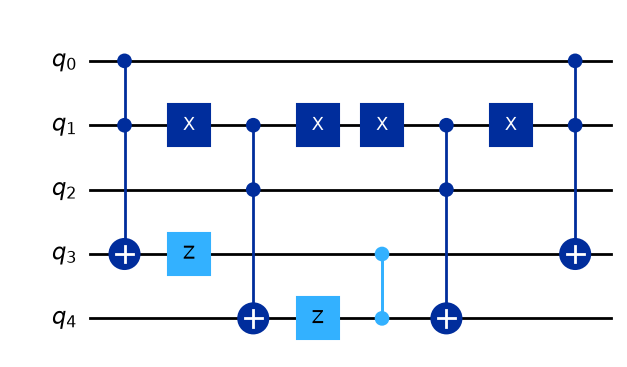

In [9]:
oracle_sop = QuantumCircuit(5, name="Oracle(SOP)")

# --- 1. Compute: raise one flag ancilla per product term ---
oracle_sop.ccx(0, 1, 3)  # flag3 (qubit 3) = x1 AND x2

oracle_sop.x(1)                 # sandwich x2 with X so the ccx below fires on (NOT x2) AND x3
oracle_sop.ccx(1, 2, 4)         # flag4 (qubit 4) = (NOT x2) AND x3
oracle_sop.x(1)                 # undo the sandwich, x2 is restored

# --- 2. Combine: OR the two flags together (Exercise 1's Z Z CZ trick) ---
oracle_sop.z(3)
oracle_sop.z(4)
oracle_sop.cz(3, 4)              # phase flips iff flag3 OR flag4 is 1

# --- 3. Uncompute: reset both flags back to |0> so they don't leak entanglement ---
oracle_sop.x(1)
oracle_sop.ccx(1, 2, 4)          # undo flag4
oracle_sop.x(1)
oracle_sop.ccx(0, 1, 3)          # undo flag3

oracle_sop.draw("mpl")



Run the check cell above again, it should now report a match against `['001', '101', '110', '111']` with ~0 ancilla leakage.
</details>


### Marking an arbitrary target state

What if we want to design a oracle, for a given solution? The trick: sandwich a multi-controlled-Z gate between `X` gates on the qubits that should be `0` in the target. This temporarily "flips" those qubits so the all-ones pattern lines up with our target, applies the phase flip, then flips them back.

This already assumes that we know the solution, which we should seek for.
But we just use it for the demo of the Grover's algorithm.

Let's write a general function that builds an oracle for *any* target bitstring, on *any* number of qubits.

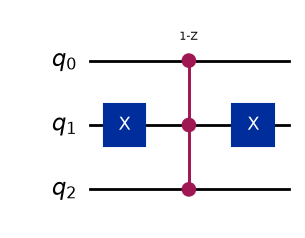

In [10]:
def grover_oracle(n_qubits: int, target: str) -> QuantumCircuit:
    """Return an oracle circuit that flips the phase of the |target> basis state.

    target is a bitstring like "101", read left-to-right as qubit n-1 ... qubit 0
    (Qiskit's little-endian convention: target[-1] corresponds to qubit 0).
    """
    if len(target) != n_qubits:
        raise ValueError("target bitstring length must equal n_qubits")

    qc = QuantumCircuit(n_qubits, name=f"Oracle(|{target}>)")

    # target[-1] is qubit 0, target[-2] is qubit 1, etc.
    zero_qubits = [i for i, bit in enumerate(reversed(target)) if bit == "0"]

    # Flip 0-bits to 1 so the target becomes the all-ones pattern
    if zero_qubits:
        qc.x(zero_qubits)

    # Apply a phase flip when ALL qubits are |1>
    if n_qubits == 1:
        qc.z(0)
    else:
        qc.append(MCMTGate(ZGate(), n_qubits - 1, 1), range(n_qubits))

    # Undo the flips
    if zero_qubits:
        qc.x(zero_qubits)

    return qc


# Sanity check: oracle for target "101" on 3 qubits
oracle_demo = grover_oracle(3, "101")
oracle_demo.draw("mpl")

Let's verify this oracle actually does what we claim: it should leave every basis state's amplitude alone *except* flip the sign of $|101\rangle$.

In [11]:
oracle_check(oracle_demo, n_qubits=3)

|000> -> phase factor +1
|001> -> phase factor +1
|010> -> phase factor +1
|011> -> phase factor +1
|100> -> phase factor +1
|101> -> phase factor -1
|110> -> phase factor +1
|111> -> phase factor +1


Exactly as expected: only $|101\rangle$ picks up a $-1$ phase. Every other state is untouched. This is our oracle working correctly.

## 5. Building block 2: the Diffuser

The diffuser reflects the state about the uniform superposition $|s\rangle$:

$$
U_s = 2|s\rangle\langle s| - I
$$

**Recipe: H, oracle-about-zero, H.** The middle step is *identical in structure* to the oracle we just built, with target $= |0\rangle^{\otimes n}$:

**The diffuser is just an oracle for the all-zero string, wrapped in Hadamards**.

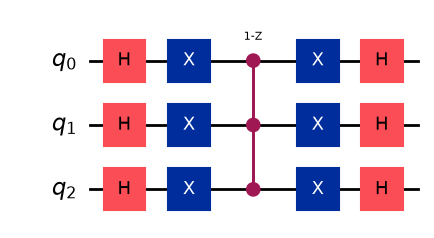

In [12]:
def grover_diffuser(n_qubits: int) -> QuantumCircuit:
    """Return the Grover diffusion operator (inversion about the mean) on n_qubits."""
    qc = QuantumCircuit(n_qubits, name="Diffuser")

    qc.h(range(n_qubits))
    # Reuse our oracle builder: mark the |00...0> state, which after the
    # surrounding Hadamards implements "reflect about |s>"
    qc.compose(grover_oracle(n_qubits, "0" * n_qubits), inplace=True)
    qc.h(range(n_qubits))

    return qc


grover_diffuser(3).draw("mpl")

### Cross-check: Qiskit's built-in `grover_operator`

We built `grover_oracle` + `grover_diffuser` by hand to see exactly what's inside them. Qiskit also ships a ready-made helper, `qiskit.circuit.library.grover_operator`, which bundles a phase oracle and the diffuser into one circuit:

$$
\mathcal{Q} = \big(H^{\otimes n} \mathcal{S}_0 H^{\otimes n}\big)\, \mathcal{S}_f
$$

Let's confirm it implements the same operation as our hand-built oracle-then-diffuser pair (up to an overall global phase, which never affects measurement probabilities).

Hand-built oracle+diffuser == qiskit's grover_operator (up to global phase)? True


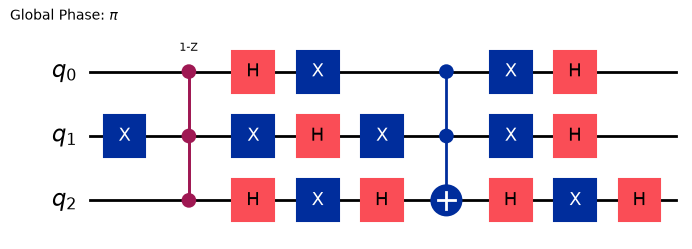

In [13]:
from qiskit.circuit.library import grover_operator
from qiskit.quantum_info import Operator

# Our hand-built version: one oracle call followed by one diffuser call
handbuilt_iterate = QuantumCircuit(3)
handbuilt_iterate.compose(grover_oracle(3, "101"), inplace=True)
handbuilt_iterate.compose(grover_diffuser(3), inplace=True)

# Qiskit's built-in version: just needs the phase oracle
builtin_iterate = grover_operator(grover_oracle(3, "101"))

equivalent = Operator(handbuilt_iterate).equiv(Operator(builtin_iterate))
print(f"Hand-built oracle+diffuser == qiskit's grover_operator (up to global phase)? {equivalent}")

builtin_iterate.draw("mpl")

## 6. Putting it together: the full Grover circuit

### How many iterations, $r$?

As derived in Section 3, each iteration rotates the state by $2\theta$ where $\sin\theta = 1/\sqrt{N}$, and the optimal count is

$$
r \approx \left\lfloor \frac{\pi}{4}\sqrt{N} \right\rfloor
$$

N = 8 states, optimal iterations r = 2


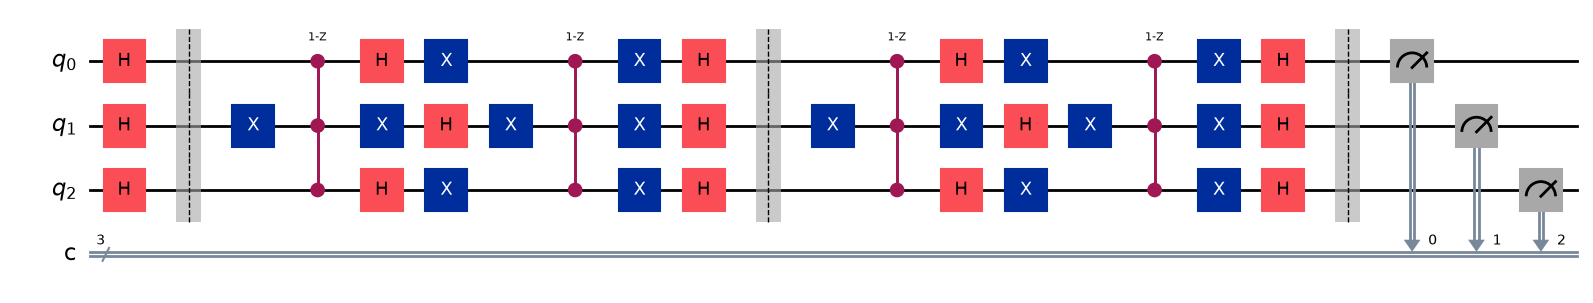

In [14]:
def grover_circuit(n_qubits: int, target: str, iterations: int = None) -> QuantumCircuit:
    """Build the full Grover search circuit for a single marked target."""
    N = 2 ** n_qubits
    if iterations is None:
        iterations = max(1, int(np.floor(np.pi / 4 * np.sqrt(N))))

    qc = QuantumCircuit(n_qubits, n_qubits, name="Grover")

    # Step 1: uniform superposition
    qc.h(range(n_qubits))
    qc.barrier()

    # Step 2: repeated oracle + diffuser
    oracle = grover_oracle(n_qubits, target)
    diffuser = grover_diffuser(n_qubits)
    for _ in range(iterations):
        qc.compose(oracle, inplace=True)
        qc.compose(diffuser, inplace=True)
        qc.barrier()

    # Step 3: measure
    qc.measure(range(n_qubits), range(n_qubits))

    return qc


n_qubits = 3
target = "101"
N = 2 ** n_qubits
optimal_r = max(1, int(np.floor(np.pi / 4 * np.sqrt(N))))
print(f"N = {N} states, optimal iterations r = {optimal_r}")

qc = grover_circuit(n_qubits, target)
qc.draw("mpl")

## 7. Running the algorithm

Let's run this on Qiskit Aer's simulator using the `SamplerV2` primitive (the modern, recommended way to get measurement results in Qiskit 2.x) and look at the results.

Measurement counts: {'101': 1890, '110': 16, '100': 18, '111': 16, '000': 9, '011': 18, '010': 22, '001': 11}


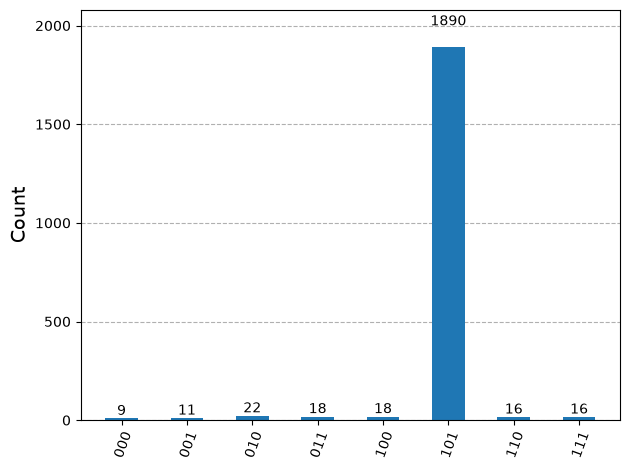

In [15]:
simulator = AerSimulator()
sampler = Sampler()

qc_isa = transpile(qc, backend=simulator)
job = sampler.run([qc_isa], shots=2000)
result = job.result()
counts = result[0].data.c.get_counts()

print("Measurement counts:", counts)
plot_histogram(counts)

You should see the bar for `101` towering over all the others, often above 90-95% probability, even though we're searching among 8 equally likely possibilities. That's Grover's algorithm working: a single quantum circuit run, with **only 2 oracle calls**, finds the marked item with high confidence, versus a classical average of ~4 checks (and up to 8 in the worst case) for this tiny example. The gap becomes dramatic as $N$ grows.

## 8. What if we pick the wrong number of iterations?

Remember the geometric picture: each iteration rotates the state vector by a fixed angle. If we rotate too little, we haven't reached the winner yet. If we rotate too much, we **overshoot past it** and probability starts dropping again! Let's sweep over several iteration counts and watch the success probability rise and fall.

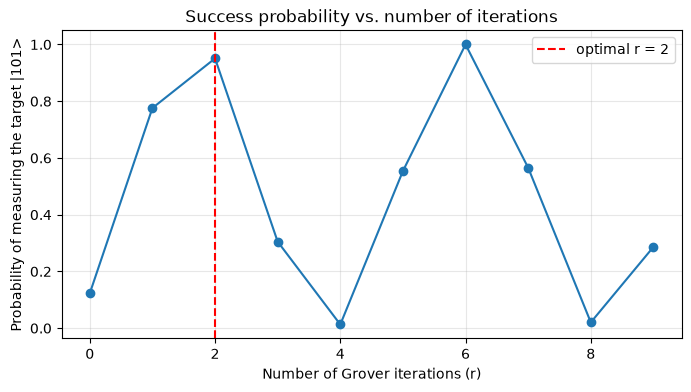

In [16]:
success_probs = []
iteration_range = range(0, 10)

for r in iteration_range:
    test_qc = grover_circuit(n_qubits, target, iterations=r)
    test_qc_isa = transpile(test_qc, backend=simulator)
    job = sampler.run([test_qc_isa], shots=2000)
    counts = job.result()[0].data.c.get_counts()
    prob = counts.get(target, 0) / sum(counts.values())
    success_probs.append(prob)

plt.figure(figsize=(8, 4))
plt.plot(list(iteration_range), success_probs, marker="o")
plt.axvline(optimal_r, color="red", linestyle="--", label=f"optimal r = {optimal_r}")
plt.xlabel("Number of Grover iterations (r)")
plt.ylabel(f"Probability of measuring the target |{target}>")
plt.title("Success probability vs. number of iterations")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Notice the curve rises, peaks near our computed optimal $r$, then **falls back down** and would eventually oscillate if we kept going. This is the rotation picture in action, the state vector sweeps past $|w\rangle$ and heads back toward $|s'\rangle$ if you keep iterating. Choosing $r$ correctly matters!

This also generalizes to $M \geq 1$ winning states out of $N$: the oracle just needs to flip the phase of every winning state, and the optimal iteration count becomes

$$
r \approx \left\lfloor \frac{\pi}{4}\sqrt{\frac{N}{M}} \right\rfloor
$$

More winners means a larger rotation angle $\theta$ per step (since $\sin\theta = \sqrt{M/N}$), so fewer iterations are needed to reach $|w\rangle$.

### Exercise 3: plot the histograms at r=1 and r=3

Using `grover_circuit` from Section 6, build and run the circuit at `iterations=1` and again at `iterations=3`, then plot each histogram (same pattern as Section 7's `run-code` cell). Compare both against the `optimal_r` result from Section 7 and the curve above: which one undershoots, and which one overshoots?

In [17]:
# Build, run, and plot the histogram for r=1, then for r=3.
# Write your code here.


<details>
<summary><b>Solution (click to expand)</b></summary>


In [18]:
for r_test in [1, 3]:
    test_qc = grover_circuit(n_qubits, target, iterations=r_test)
    test_qc_isa = transpile(test_qc, backend=simulator)
    job = sampler.run([test_qc_isa], shots=2000)
    counts = job.result()[0].data.c.get_counts()
    print(f"r = {r_test}: {counts}")
    plot_histogram(counts, title=f"r = {r_test}")


r = 1: {'101': 1560, '011': 64, '000': 63, '001': 63, '111': 61, '110': 62, '100': 55, '010': 72}
r = 3: {'100': 200, '101': 627, '010': 196, '110': 207, '000': 194, '111': 199, '001': 197, '011': 180}



`r=1` undershoots (below the optimal `r=2` from Section 7, still climbing the curve), while `r=3` overshoots (past the peak, probability has started dropping again). Both should still favor `101` over the other outcomes, just less strongly than the optimal r=2 run in Section 7.
</details>


## 9. Building an oracle from logical rules (a Minesweeper puzzle)

Every oracle we've built so far, `grover_oracle(n_qubits, target)`, is handed the answer directly: you pass in the winning bitstring `target`, and the function just wires up gates that recognize *that specific string*. That's fine for learning the mechanics, but it sidesteps the real point of Grover's algorithm: in practice, you almost never know the answer in advance. What you have is a *rule* that lets you check whether a candidate is correct, and Grover's algorithm searches through candidates for you.

Let's build a genuine example of this: a tiny **Minesweeper puzzle**. We have a small 2×3 board. Two cells are already revealed and show a number (how many mines are hiding among that cell's neighbors). The other four cells are unknown, they might be mines or might be safe, and we don't know which.

We'll treat each unknown cell as one qubit (`1` = mine, `0` = safe), and build an oracle that flips the phase of a candidate assignment **if and only if it's consistent with both revealed numbers**, computed purely from the board's geometry and the clue numbers, never from knowing the actual mine locations ahead of time.

### The puzzle

Here's the board we'll solve. Revealed cells show their clue number; unknown cells are labeled with the qubit index that represents them.

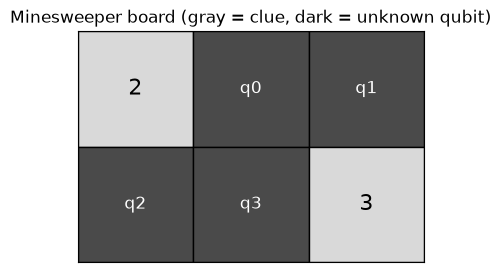

In [19]:
CLUES = {(0, 0): 2, (1, 2): 3}
UNKNOWN_CELLS = [(0, 1), (0, 2), (1, 0), (1, 1)]

fig, ax = plt.subplots(figsize=(4.5, 3))
for r in range(2):
    for c in range(3):
        if (r, c) in CLUES:
            ax.add_patch(plt.Rectangle((c, 1 - r), 1, 1, facecolor="#d9d9d9", edgecolor="black"))
            ax.text(c + 0.5, 1 - r + 0.5, str(CLUES[(r, c)]), ha="center", va="center", fontsize=16)
        else:
            q = UNKNOWN_CELLS.index((r, c))
            ax.add_patch(plt.Rectangle((c, 1 - r), 1, 1, facecolor="#4a4a4a", edgecolor="black"))
            ax.text(c + 0.5, 1 - r + 0.5, f"q{q}", ha="center", va="center", fontsize=12, color="white")

ax.set_xlim(0, 3)
ax.set_ylim(0, 2)
ax.set_xticks([])
ax.set_yticks([])
ax.set_aspect("equal")
ax.set_title("Minesweeper board (gray = clue, dark = unknown qubit)")
plt.show()

### From board geometry to clue constraints

Each clue's number counts mines among its neighboring cells (including diagonals), clipped to the board edges. For each clue cell, we look at its neighbors, keep only the ones that are still unknown (the revealed clue cells themselves are never mines), and note which qubit index each corresponds to. This gives us, for every clue, a pair `(k, neighbor_qubits)`: "exactly `k` of these qubits must be 1."

We compute this table once from the board, never from knowing where the mines actually are:

| Clue cell | k (mines) | neighbor qubits | degree |
|---|---|---|---|
| (0,0) | 2 | q0, q2, q3 | 3 |
| (1,2) | 3 | q0, q1, q3 | 3 |

In [20]:
def neighbors(cell):
    r, c = cell
    return [
        (r + dr, c + dc)
        for dr in (-1, 0, 1)
        for dc in (-1, 0, 1)
        if (dr, dc) != (0, 0) and 0 <= r + dr < 2 and 0 <= c + dc < 3
    ]


CLUE_SPECS = []
for cell, k in CLUES.items():
    neighbor_qubits = [UNKNOWN_CELLS.index(n) for n in neighbors(cell) if n in UNKNOWN_CELLS]
    CLUE_SPECS.append((k, sorted(neighbor_qubits)))
    print(f"clue {cell} = {k}  ->  neighbor qubits {sorted(neighbor_qubits)}")

clue (0, 0) = 2  ->  neighbor qubits [0, 2, 3]
clue (1, 2) = 3  ->  neighbor qubits [0, 1, 3]


Before building the quantum oracle, let's sanity-check the puzzle itself: does exactly one mine layout satisfy both clues at once? This is pure classical brute force, it has nothing to do with the oracle we're about to build, it just confirms the puzzle is well-posed. With only 4 unknown cells, there are just $2^4=16$ possible layouts, small enough to check by hand if you want to.

In [21]:
import itertools

solutions = []
for bits in itertools.product([0, 1], repeat=4):
    if all(sum(bits[q] for q in qubits) == k for k, qubits in CLUE_SPECS):
        solutions.append(bits)

print(f"Found {len(solutions)} solution(s) out of 16 possible mine layouts.")
solution_bits = solutions[0]
mine_qubits = [q for q, b in enumerate(solution_bits) if b == 1]
print(f"Unique solution: mines at qubits {mine_qubits} -> cells {[UNKNOWN_CELLS[q] for q in mine_qubits]}")

Found 1 solution(s) out of 16 possible mine layouts.
Unique solution: mines at qubits [0, 1, 3] -> cells [(0, 1), (0, 2), (1, 1)]


### Building block: "exactly k of d" flag

Each clue needs a small circuit that raises a flag qubit to `1` exactly when precisely `k` of its `d` neighbor qubits are `1`. Here's the trick: for every one of the $\binom{d}{k}$ ways to choose *which* `k` of the `d` qubits are the mines, temporarily flip the remaining `d - k` qubits (so "should be safe" lines up with `0`), apply a single `d`-controlled-X onto the flag, then flip back. This is exactly the same "X-sandwich + multi-controlled gate" trick `grover_oracle` already uses, we're just repeating it once per matching pattern.

Since any real input can only ever match *one* such pattern (a bitstring either has Hamming weight `k` or it doesn't, and if it does, exactly one "which positions are the 1s" pattern fits), the flag toggles at most once, so a plain MCX is enough, no risk of double-toggling back to 0.

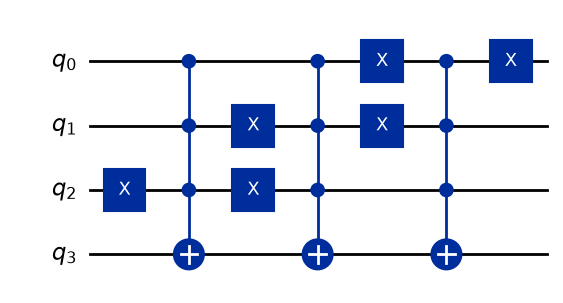

In [22]:
def append_exactly_k_flag(qc: QuantumCircuit, inputs: list[int], flag: int, k: int) -> None:
    """Toggle `flag` iff exactly k of the qubits in `inputs` are |1>."""
    d = len(inputs)
    for subset in itertools.combinations(range(d), k):
        zero_qubits = [inputs[j] for j in range(d) if j not in subset]
        if zero_qubits:
            qc.x(zero_qubits)
        qc.mcx(inputs, flag)
        if zero_qubits:
            qc.x(zero_qubits)


# Demo: d=3 inputs (qubits 0,1,2), k=2, flag on qubit 3
demo = QuantumCircuit(4, name="exactly_2_of_3")
append_exactly_k_flag(demo, inputs=[0, 1, 2], flag=3, k=2)
demo.draw("mpl")

Let's verify this sub-circuit does exactly what we claim, for every possible input.

In [23]:
all_correct = True
for bits in itertools.product([0, 1], repeat=3):
    # qubit0=bits[0], qubit1=bits[1], qubit2=bits[2], flag qubit3 starts at 0
    # Statevector.from_label reads left-to-right as qubit (n-1)...qubit 0
    label = "0" + str(bits[2]) + str(bits[1]) + str(bits[0])
    sv = Statevector.from_label(label)
    sv_after = sv.evolve(demo)
    outcome = max(sv_after.probabilities_dict(), key=sv_after.probabilities_dict().get)
    measured_flag = int(outcome[0])  # leftmost char = qubit 3 (flag)
    expected_flag = 1 if sum(bits) == 2 else 0
    ok = measured_flag == expected_flag
    all_correct &= ok
    print(f"inputs={bits} -> flag={measured_flag} (expected {expected_flag}) {'OK' if ok else 'MISMATCH'}")

print("\nAll cases correct!" if all_correct else "\nSomething is wrong!")

inputs=(0, 0, 0) -> flag=0 (expected 0) OK
inputs=(0, 0, 1) -> flag=0 (expected 0) OK
inputs=(0, 1, 0) -> flag=0 (expected 0) OK
inputs=(0, 1, 1) -> flag=1 (expected 1) OK
inputs=(1, 0, 0) -> flag=0 (expected 0) OK
inputs=(1, 0, 1) -> flag=1 (expected 1) OK
inputs=(1, 1, 0) -> flag=1 (expected 1) OK
inputs=(1, 1, 1) -> flag=0 (expected 0) OK

All cases correct!


### Assembling the full oracle

Combine two "exactly k of d" flags, one per clue, into the full Minesweeper oracle:

1. **Compute**: raise each clue's flag ancilla iff that clue's constraint holds. → 2 flags, each `1` iff its clue is satisfied.
2. **Combine**: flip the global phase iff *both* flags are `1`, one $CZ$ across the flag register (exactly the AND-oracle from Section 4!).
3. **Uncompute**: re-run step 1 to reset every flag back to `0` (each construction is its own inverse).

**4 primary qubits + 2 flag ancillas = 6 qubits total.**

Oracle circuit: 6 qubits, 21 gates, depth 16


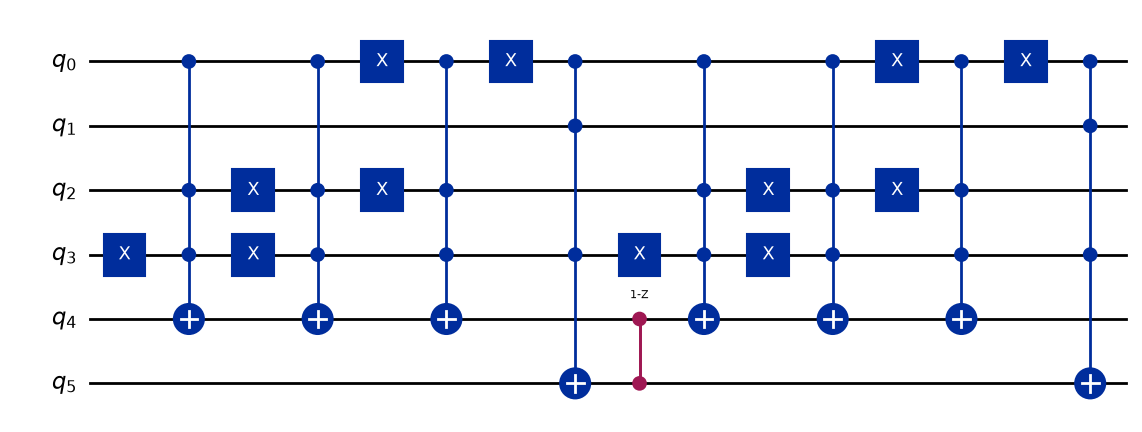

In [24]:
def minesweeper_oracle(clue_specs: list[tuple[int, list[int]]]) -> QuantumCircuit:
    """Build a Grover oracle that flips the phase of any 4-qubit assignment
    satisfying every Minesweeper clue.

    clue_specs: list of (k, neighbor_qubit_indices), one per clue, describing only
    the puzzle's geometry and clue numbers. The solution itself is never passed in.

    Returns a circuit on 4 + len(clue_specs) qubits: qubits 0..3 are the primary
    register (unknown cells), and each subsequent qubit is a flag ancilla for one clue.
    """
    n_primary = 4
    n_clues = len(clue_specs)
    flags = list(range(n_primary, n_primary + n_clues))

    qc = QuantumCircuit(n_primary + n_clues, name="Oracle(Minesweeper)")

    # Compute: raise each clue's flag iff its constraint holds
    for flag, (k, neighbor_qubits) in zip(flags, clue_specs):
        append_exactly_k_flag(qc, neighbor_qubits, flag, k)

    # Combine: flip phase iff ALL flags are 1
    qc.append(MCMTGate(ZGate(), n_clues - 1, 1), flags)

    # Uncompute: reset every flag ancilla back to |0>
    for flag, (k, neighbor_qubits) in zip(flags, clue_specs):
        append_exactly_k_flag(qc, neighbor_qubits, flag, k)

    return qc


mine_oracle = minesweeper_oracle(CLUE_SPECS)
print(f"Oracle circuit: {mine_oracle.num_qubits} qubits, {mine_oracle.size()} gates, depth {mine_oracle.depth()}")
mine_oracle.draw("mpl")

Let's verify the oracle flips the phase on exactly the expected solution, and only that solution, and that both ancillas really do return to `|0\rangle`. With only 4 primary qubits, we can afford to just evolve the equal superposition of all 16 primary-register combinations with both ancillas at `0` and read off every amplitude at once.

In [25]:
init = QuantumCircuit(6)
init.h(range(4))  # equal superposition over all 16 primary states; ancillas stay at |0>

sv_after = Statevector(init).evolve(mine_oracle)
amplitudes = sv_after.data

flipped = [i for i in range(16) if amplitudes[i].real < -1e-6]
ancilla_leakage = np.sum(np.abs(amplitudes[16:]) ** 2)

print(f"States with a flipped phase: {flipped}")
flipped_bits = [(flipped[0] >> q) & 1 for q in range(4)]
print(f"That state's mine qubits: {[q for q, b in enumerate(flipped_bits) if b]}")
print(f"Matches classical solution (mines at {mine_qubits})? {sorted(q for q, b in enumerate(flipped_bits) if b) == sorted(mine_qubits)}")
print(f"Probability leaked into ancilla-nonzero states: {ancilla_leakage:.2e} (should be ~0)")

States with a flipped phase: [11]
That state's mine qubits: [0, 1, 3]
Matches classical solution (mines at [0, 1, 3])? True
Probability leaked into ancilla-nonzero states: 9.21e-32 (should be ~0)


Exactly one state picks up a `-1` phase, it matches the classical brute-force solution from earlier, and no probability leaked into the ancilla register. `minesweeper_oracle` is a clean phase oracle, built entirely from the clue geometry, never from the answer.

### Running Grover's algorithm on the Minesweeper oracle

- Reuse `grover_diffuser` unchanged, it only touches the primary 4-qubit register.
- $N = 2^4 = 16$, single winner → $r \approx \lfloor \frac{\pi}{4}\sqrt{16} \rfloor = 3$.
- Circuit needs 6 qubits (4 primary + 2 ancillas) but only 4 classical bits, we measure just the primary register. Small enough to run directly on the same simulator as every earlier section, no need to skip straight to a fake/real backend.

N = 16, optimal iterations r = 3
Most measured bitstring: 1011 (1942/2000 shots)


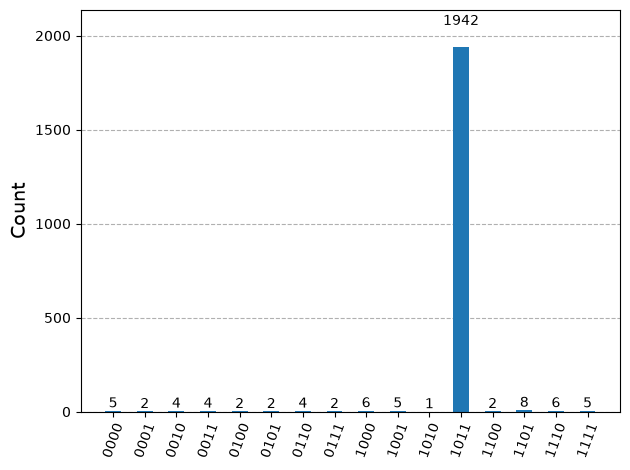

In [26]:
N_mine = 2 ** 4
r_mine = max(1, int(np.floor(np.pi / 4 * np.sqrt(N_mine))))
print(f"N = {N_mine}, optimal iterations r = {r_mine}")

qc_mine = QuantumCircuit(6, 4, name="Grover-Minesweeper")
qc_mine.h(range(4))
qc_mine.barrier()

diffuser4 = grover_diffuser(4)
for _ in range(r_mine):
    qc_mine.compose(mine_oracle, qubits=range(6), inplace=True)
    qc_mine.compose(diffuser4, qubits=range(4), inplace=True)
    qc_mine.barrier()

qc_mine.measure(range(4), range(4))

qc_mine_isa = transpile(qc_mine, backend=simulator)
job = sampler.run([qc_mine_isa], shots=2000)
counts_mine = job.result()[0].data.c.get_counts()

top_result = max(counts_mine, key=counts_mine.get)
print(f"Most measured bitstring: {top_result} ({counts_mine[top_result]}/{sum(counts_mine.values())} shots)")
plot_histogram(counts_mine)

In [27]:
winning_bits = [int(b) for b in reversed(top_result)]
found_mines = [UNKNOWN_CELLS[q] for q, b in enumerate(winning_bits) if b == 1]
print(f"Grover found mines at: {found_mines}")
print(f"Classical brute force found mines at: {[UNKNOWN_CELLS[q] for q in mine_qubits]}")

Grover found mines at: [(0, 1), (0, 2), (1, 1)]
Classical brute force found mines at: [(0, 1), (0, 2), (1, 1)]


The winning bitstring dominates the histogram (well above 90% of shots out of 16 equally likely candidates), and it matches the classical brute-force solution, found by a genuinely *logical* oracle that was only ever given clue numbers and adjacency, never the mine locations themselves. This is the pattern behind every real-world use of Grover's algorithm: write a checker circuit for your constraints, and let amplitude amplification do the searching.

### Exercise 4: optimal $r$ for a larger Minesweeper board

Suppose instead of a 2x3 board with 4 unknown cells, we had a 3x3 board with only 2 revealed clue cells, leaving **7 unknown cells** (so $N = 2^7 = 128$ possible mine layouts) and still a single valid solution consistent with both clues.

Using the same optimal-iteration formula from Section 8 ($r \approx \lfloor \frac{\pi}{4}\sqrt{N/M} \rfloor$, with $M=1$ winner here), what value of $r$ should you use? Compute it, then compare to `r_mine = 3` used for the 4-qubit board above: how much did $r$ actually grow when $N$ quadrupled from 16 to 128?

In [28]:
# Compute the optimal r for N = 128 (7 unknown cells), M = 1 winner.
# Write your code here.


<details>
<summary><b>Solution (click to expand)</b>


In [29]:
N_larger = 2 ** 7
r_larger = max(1, int(np.floor(np.pi / 4 * np.sqrt(N_larger))))
print(f"N = {N_larger}: optimal r = {r_larger}")
print(f"N = {N_mine}: optimal r = {r_mine}")


N = 128: optimal r = 8
N = 16: optimal r = 3



`r = 8` for the 7-qubit board, versus `r_mine = 3` for the 4-qubit board: $N$ grew 8x (16 to 128), but $r$ only grew from 3 to 8, not 8x, since $r = O(\sqrt{N})$. This is exactly the quadratic speedup at work: doubling the search space's *size* only costs about $\sqrt{2} \approx 1.41$x more iterations, not 2x. It's also why the routed circuit for a bigger Minesweeper board gets deep so fast in Section 10 below: 8 iterations means 8 copies of an oracle that's already several multi-controlled-X gates wide, each one compounding the two-qubit-gate depth after routing onto sparse real hardware.
</details>

## 10. Running on real IBM Quantum hardware

Everything above ran on Aer's statevector simulator, which happily handles the 6-qubit Minesweeper circuit. Real QPUs are a different story: qubits are only physically connected to a few neighbors (the *coupling map*), gates are noisy, and coherence only lasts a limited time, so circuit **depth**, especially two-qubit-gate depth, is what determines whether a result is signal or noise.

Let's check whether the Minesweeper circuit could realistically run on hardware, using [`FakeFez`](https://quantum.cloud.ibm.com/learning/en/modules/computer-science/grovers), a fake backend that mimics a real 156-qubit IBM device's coupling map and noise, without spending real QPU time.

In [30]:
from qiskit_ibm_runtime.fake_provider import FakeFez
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

fake_backend = FakeFez()
pm_fake = generate_preset_pass_manager(target=fake_backend.target, optimization_level=3, seed_transpiler=42)
qc_mine_transpiled = pm_fake.run(qc_mine)

print(f"Minesweeper circuit ({r_mine} iterations) transpiled for {fake_backend.name}:")
print(f"  depth:    {qc_mine_transpiled.depth()}")
print(f"  2q depth: {qc_mine_transpiled.depth(lambda instr: instr.operation.num_qubits == 2)}")
print(f"  gates:    {qc_mine_transpiled.size()}")

Minesweeper circuit (3 iterations) transpiled for fake_fez:
  depth:    2116
  2q depth: 593
  gates:    2980


That depth is still in the thousands, and the two-qubit-gate depth alone is in the hundreds, well beyond what any current QPU's coherence time can support, even though our puzzle is now tiny. The culprit: the Minesweeper oracle's "exactly-$k$-of-$d$" flag logic needs several multi-controlled-X gates per clue, and on a sparse, real hardware coupling map (each qubit wired to only a handful of neighbors, not all-to-all) those decompose into long chains of SWAPs. Repeated across $r=3$ iterations, the routing overhead compounds quickly.

**So we keep the 6-qubit Minesweeper problem exactly as it is for simulation** (nothing above this point changes), but for an actual hardware run we need an even simpler Grover instance. This is completely standard: real devices today are noisy enough that only shallow circuits survive, so hardware demos use toy-sized problems even when the same algorithm scales to bigger ones on a simulator.

We'll reuse this notebook's original 3-qubit, single-target example (`grover_oracle(3, "101")`, optimal $r=2$) and walk through the four-step **Qiskit pattern** for running on real hardware, following the structure from [IBM Quantum Learning's Grover's algorithm module](https://quantum.cloud.ibm.com/learning/en/modules/computer-science/grovers):

1. **Map** the problem to a quantum circuit.
2. **Optimize** the circuit for the target hardware (transpile).
3. **Execute** on the QPU.
4. **Post-process** the results.

### Step 1: Map, build the circuit

Same problem as Sections 4-7: 3 qubits, target `"101"`, optimal $r=2$ iterations. This time we build it with `grover_operator` (Section 5's cross-check) and `.power(r)`, then add the initial Hadamards and a measurement.

N = 8, r = 2
Logical circuit: depth 4, 8 gates


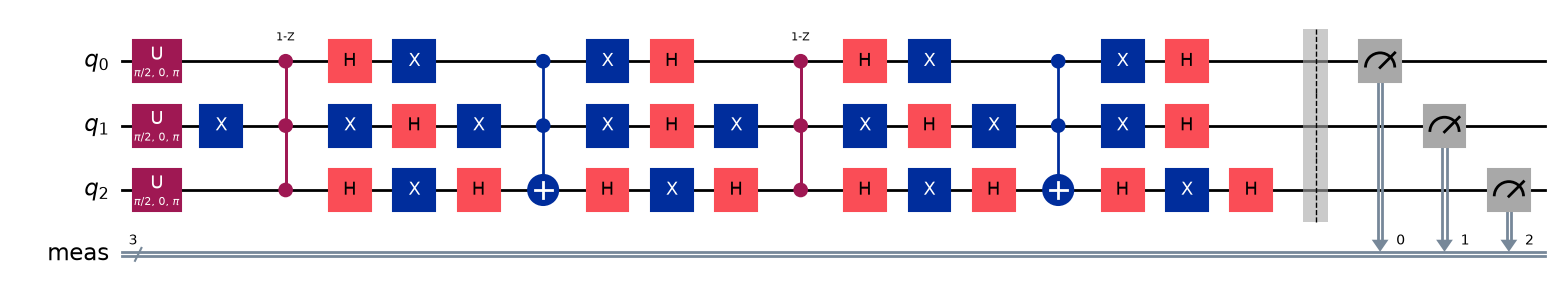

In [31]:
hw_n_qubits = 3
hw_target = "101"
hw_N = 2 ** hw_n_qubits
hw_r = max(1, int(np.floor(np.pi / 4 * np.sqrt(hw_N))))

hw_oracle = grover_oracle(hw_n_qubits, hw_target)
hw_grover_op = grover_operator(hw_oracle).power(hw_r)

qc_hw = QuantumCircuit(hw_n_qubits)
qc_hw.h(range(hw_n_qubits))
qc_hw.compose(hw_grover_op, inplace=True)
qc_hw.measure_all()

print(f"N = {hw_N}, r = {hw_r}")
print(f"Logical circuit: depth {qc_hw.depth()}, {qc_hw.size()} gates")
qc_hw.decompose().draw("mpl")

### Step 2: Optimize, transpile for the target backend

Connect to the IBM Quantum Runtime service and pick the least-busy operational real backend, then transpile at `optimization_level=3`. The preset pass manager handles layout, routing, and gate translation automatically, so there's no need for manual qubit placement.

In [32]:
from qiskit_ibm_runtime import QiskitRuntimeService

service = QiskitRuntimeService()
backend = service.least_busy(operational=True, simulator=False)
print(f"Selected backend: {backend.name} ({backend.num_qubits} qubits)")

pm_hw = generate_preset_pass_manager(target=backend.target, optimization_level=3)
qc_hw_isa = pm_hw.run(qc_hw)

print(f"Transpiled for {backend.name}:")
print(f"  depth:    {qc_hw_isa.depth()}")
print(f"  2q depth: {qc_hw_isa.depth(lambda instr: instr.operation.num_qubits == 2)}")
print(f"  gates:    {qc_hw_isa.size()}")

Selected backend: ibm_fez (156 qubits)
Transpiled for ibm_fez:
  depth:    134
  2q depth: 37
  gates:    189


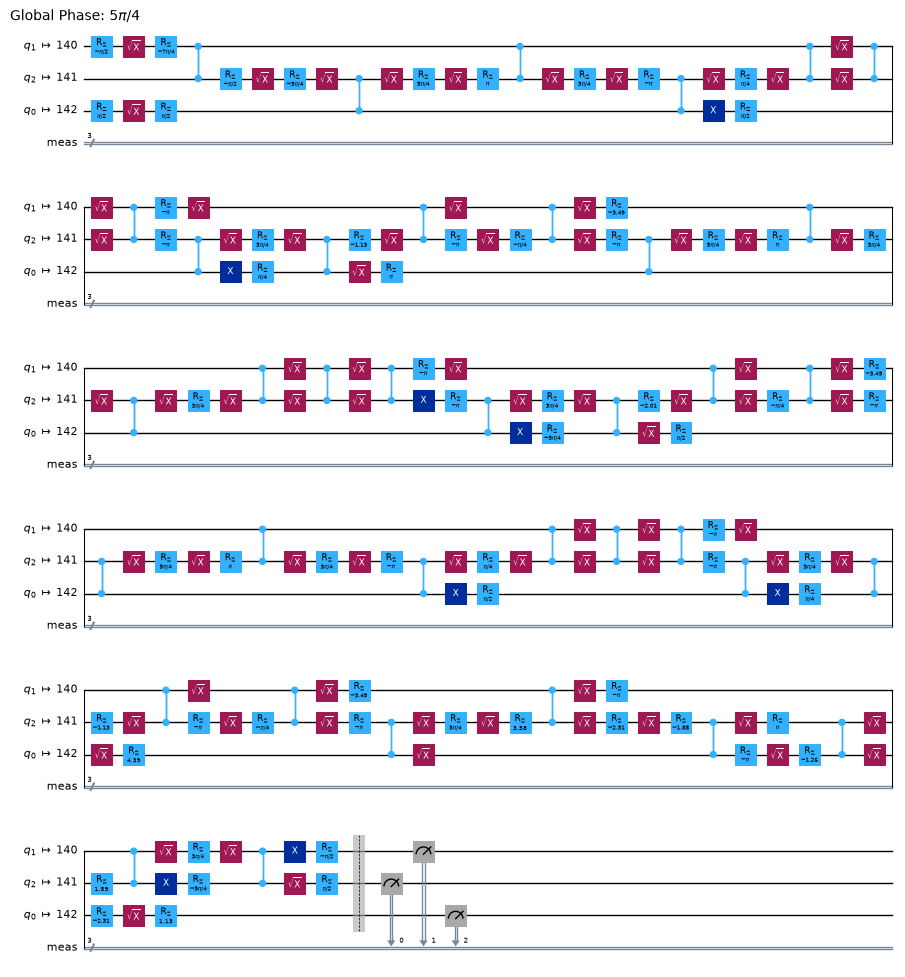

In [33]:
qc_hw_isa.draw("mpl", scale=0.5)

Depth here should land in the low hundreds (comparable to IBM's own tutorial figures for an equivalent single-target 3-4 qubit Grover instance), small enough to fit well within current hardware coherence budgets, unlike the Minesweeper circuit above.

### Step 3: Execute, submit to the QPU

Submit `qc_hw_isa` via `SamplerV2`. **This runs on a real IBM QPU and consumes real queue time/account usage.** With `job_id = None`, running the cell below submits a new job and prints its ID. If the queue is long, you can come back later, paste that ID into `job_id`, and re-run the cell to fetch the same job's results without submitting again.

In [ ]:
from qiskit_ibm_runtime import SamplerV2

# Set this to an existing job ID to fetch a previously submitted job's results
# instead of queueing a new one. Leave it None to submit fresh and print the
# resulting job ID, which you can paste in here on a later run.
job_id = None

if job_id is None:
    hw_sampler = SamplerV2(mode=backend)
    hw_sampler.options.default_shots = 10_000
    hw_job = hw_sampler.run([qc_hw_isa])
    job_id = hw_job.job_id()
    print(f"Job ID: {job_id}")
else:
    hw_job = service.job(job_id)
    print(f"Fetching existing job: {job_id}")

hw_result = hw_job.result()
hw_counts = hw_result[0].data.meas.get_counts()
print("Measurement counts:", hw_counts)

Fetching existing job: da7j2ne0ukec7383c3ig
Measurement counts: {'101': 7763, '011': 278, '001': 424, '111': 387, '100': 399, '110': 278, '010': 210, '000': 261}


### Step 4: Post-process, plot the distribution

Compare the real-hardware distribution to the ideal simulator result from Section 7. Expect `101` to still dominate, but with visible noise: other bitstrings will get non-trivial probability, unlike the near-perfect simulator histogram, because real gates and readout aren't perfect.

P(measure |101>) on ibm_fez: 0.776 (10000 shots)


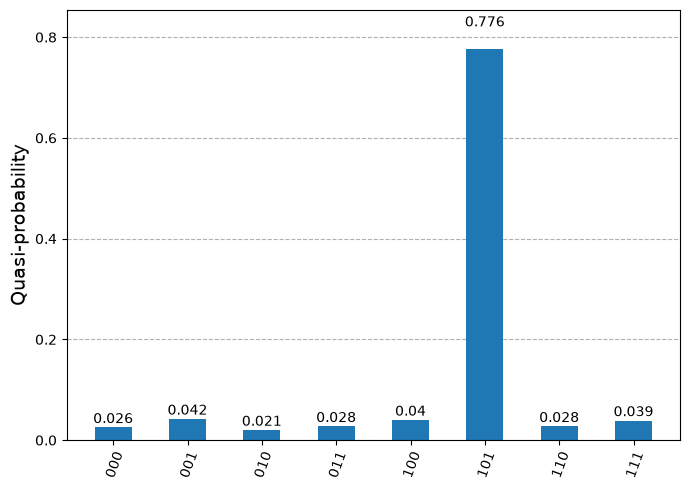

In [35]:
from qiskit.visualization import plot_distribution

hw_shots = sum(hw_counts.values())
hw_success_prob = hw_counts.get(hw_target, 0) / hw_shots
print(f"P(measure |{hw_target}>) on {backend.name}: {hw_success_prob:.3f} ({hw_shots} shots)")
plot_distribution(hw_counts)

## 11. Recap and key takeaways

| Concept | What it does |
|---|---|
| **Uniform superposition** ($H^{\otimes n}$) | Puts all $N$ possibilities into play simultaneously |
| **Oracle** | Flips the phase (sign) of the winning state(s), marking them invisibly |
| **Diffuser** | Reflects about the average amplitude, turning the phase flip into a boosted probability |
| **One Grover iteration** (oracle + diffuser) | Rotates the state vector by a fixed angle toward the winner |
| **Optimal iteration count** $r \approx \frac{\pi}{4}\sqrt{N/M}$ | Stops the rotation right when it's aligned with the winner(s); too few or too many iterations both hurt |

**Why this matters beyond search:** the oracle + diffuser pattern ("amplitude amplification") is a general-purpose quantum subroutine. It's reused inside many other algorithms, quantum counting, quantum walks, and various optimization and machine-learning algorithms all borrow this same amplify-the-good-answers trick.

### Where to go next

- Try building an oracle for a *computed* condition (e.g., "mark $x$ if $x$ is even") instead of a fixed bitstring, this is how Grover's algorithm is used for real problems like SAT-solving. (We did exactly this in the Minesweeper bonus section above, see how a checker built from puzzle rules, not a hardcoded answer, still lets Grover find the unique solution.)
- Look up **quantum counting**, which uses phase estimation on top of the Grover iterate to estimate $M$ (the number of winners) without knowing it in advance.
- We already ran a small instance on real IBM Quantum hardware in Section 10 above, try scaling it up (more qubits, a harder oracle) and see how the noise grows as circuit depth increases.

## 12. Beyond Grover: why NISQ hardware needs a different family of algorithms

Grover's algorithm, like Shor's factoring algorithm, is a **fault-tolerant quantum computing (FTQC)** algorithm: its speedup guarantee assumes perfect gates and enough qubits for error correction. Section 10 above made the mismatch concrete: even a tiny, single-target instance needed hundreds of gates once routed onto real hardware, and even the small 6-qubit Minesweeper oracle was already far beyond what any current device's coherence time can survive. This isn't a bug in our implementation; it's structural. $r=O(\sqrt N)$ repetitions of an oracle+diffuser block means depth grows with problem size at exactly the rate today's noisy qubits can't tolerate.

Today's **NISQ** (Noisy Intermediate-Scale Quantum) devices call for algorithms designed around *shallow* circuits from the start, typically **variational**: a short, parameterized circuit runs on the QPU, a classical optimizer adjusts its parameters based on measured results, and the two loop together. The quantum device does only as much work as its noise budget allows; the classical computer does the rest.

### QAOA: Grover's structure, made variational

The **Quantum Approximate Optimization Algorithm (QAOA)** targets combinatorial optimization (Max-Cut, scheduling, SAT-like problems, not far from the Minesweeper-style constraint problems in Section 9) and has a structure that should look familiar:

| | Grover | QAOA |
|---|---|---|
| Phase step | Oracle $U_f$: fixed $-1$ phase flip on winners | Phase-separation $e^{-i\gamma_p H_C}$: phase proportional to how *well* a state satisfies the cost function $H_C$, angle $\gamma_p$ tunable |
| Mixing step | Diffuser $U_s$: fixed reflection about $\lvert s\rangle$ | Mixer $e^{-i\beta_p H_M}$ (usually $H_M=\sum_i X_i$): spreads amplitude between states, angle $\beta_p$ tunable |
| Repetition | Fixed $r=\lfloor\frac{\pi}{4}\sqrt{N/M}\rfloor$, no feedback | $p$ layers, with $(\gamma_i,\beta_i)$ tuned by a classical optimizer against measured cost |

Grover alternates a fixed "mark the winner" step with a fixed "amplify" step, and the $r$ that works is derived analytically in advance. QAOA keeps exactly that phase-separation/mixing alternation, but **relaxes** the phase step from a binary flip to a continuous, cost-dependent rotation, and hands the angles to a classical optimizer instead of computing them by hand, trading Grover's provable, hardware-hungry rotation for a shallow, hardware-friendly circuit whose parameters are learned. With $p=1$ layer and a phase-separation angle fixed at $\pi$, QAOA's mixing step is literally the Grover diffuser's structure; scanning $p$ and $(\gamma,\beta)$ is what recovers something Grover-like as a special case.

### Tutorials and further reading on the IBM Quantum Platform

- [Utility-scale QAOA](https://quantum.cloud.ibm.com/learning/courses/quantum-computing-in-practice/utility-scale-qaoa): the phase-separation/mixer structure above, from the ground up, on max-cut.
- [Variational quantum algorithms](https://quantum.cloud.ibm.com/learning/courses/utility-scale-quantum-computing/variational-quantum-algorithms): VQE and QAOA side by side, the two flagship NISQ variational algorithms.
- [Variational Quantum Eigensolver (VQE)](https://quantum.cloud.ibm.com/learning/courses/quantum-diagonalization-algorithms/vqe): the other major NISQ variational algorithm, aimed at ground-state energy estimation (chemistry, materials).
- [IBM Quantum Learning: full course catalog](https://quantum.cloud.ibm.com/learning/en/courses): browse everything, filterable by topic and level.